In [2]:
# Referenced/Used AI generated code and info from OpenAI GPT-4.1 through Github Copilot
# Referenced/Used AI generated code and info from OpenAI GPT-4.1 through Github Copilot (Help with importing libraries)
from pathlib import Path
import pandas as pd
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
from sklearn.model_selection import train_test_split
from peft import LoraConfig, TaskType
from torch.utils.data import Dataset
from peft import LoraConfig, get_peft_model, TaskType
from transformers import TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
# End of: Referenced/Used AI generated code and info from OpenAI GPT-4.1 through Github Copilot (Help with importing libraries)

random_state = 2026

In [3]:
# Referenced/Used AI generated code and info from OpenAI GPT-4.1 through Github Copilot (Help with rename columns, help with indexing multiple columns, help with dropping rows, help with changing column dtype)
def generate_dataset(path="/content/diabetes_binary_health_indicators_BRFSS2015.csv"):
  df = pd.read_csv(path)
  rename_cols = {
      "Diabetes_binary": "diabetes",
      "MentHlth": "days_mentally_ill",
      "Smoker": "smoking",
      "HvyAlcoholConsump": "alchohol_consumption",
      "PhysActivity": "physical_activity",
      "Fruits": "consumed_fruits",
      "Veggies": "consumed_vegetables",
      "PhysHlth": "days_physically_ill",
      "DiffWalk": "difficulty_walking",
      "GenHlth": "general_health",
  }
  columns_filter = [col for col in rename_cols.keys()]
  df = df[columns_filter]
  df = df.rename(columns=rename_cols)
  df["diabetes"] = df.diabetes.astype(int)

  df = df.dropna()
  return df
# End of: Referenced/Used AI generated code and info from OpenAI GPT-4.1 through Github Copilot (Help with rename columns, help with indexing multiple columns, help with dropping rows, help with changing column dtype)


# Referenced/Used: https://machinelearningmastery.com/navigating-imbalanced-datasets-with-pandas-and-scikit-learn/
def undersample_dataset(dataset):

  df_diabetic = dataset[dataset.diabetes == 1]
  df_non_diabetic = dataset[dataset.diabetes == 0]

  df_downsampled = df_non_diabetic.sample(n=len(df_diabetic), random_state=random_state)
  df_balanced = pd.concat([df_downsampled, df_diabetic])
  df_balanced = df_balanced.reset_index(drop=True)

  return df_balanced
# Referenced/Used: https://machinelearningmastery.com/navigating-imbalanced-datasets-with-pandas-and-scikit-learn/


# Referenced/Used AI generated code and info from OpenAI GPT-4.1 through Github Copilot (Help with checking viability with classfication model, help with understanding integration into model)
# Referenced/Used: https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset?select=diabetes_binary_health_indicators_BRFSS2015.csv
def text_format(train_dataset):
  texts = []
  for i in range(len(train_dataset)):
    features = train_dataset.iloc[i]

    consumed_vegetables = "Yes"  if features.consumed_vegetables == 1 else "No"
    consumed_fruits = "Yes"  if features.consumed_fruits == 1 else "No"
    smoking = "Yes" if features.smoking == 1 else "No"
    alcohol = "Yes" if features.alchohol_consumption == 1 else "No"
    difficulty_walking = "Yes" if features.difficulty_walking == 1 else "No"
    physically_active = "Yes" if features.physical_activity == 1 else "No"


    build_up = []
    build_up.append(f"Eats 1 or more vegetable a day: {consumed_vegetables};")
    build_up.append(f"Eats 1 or more fruit a day: {consumed_fruits};")
    build_up.append(f"Number of days spent mentally ill for last 30 days: {features.days_mentally_ill};")
    build_up.append(f"Number of days spent physically ill for last 30 days: {features.days_physically_ill};")
    build_up.append(f"Has been physically active in the last 30 days outside of work: {physically_active};")
    build_up.append(f"Has difficulty walking stairs: {difficulty_walking};")
    build_up.append(f"Overall health score from self assessment (1=excellent 2=very good 3=good 4=fair 5=poor): {features.general_health};")
    build_up.append(f"Has smoked more than 100 cigarettes: {smoking};")
    build_up.append(f"Heavy alchohol consumption (men=14 or more drinks a week, women=7 or more drink a week): {alcohol};")

    text = "".join(build_up)

    texts.append(text)
  return texts
# End of: Referenced/Used: https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset?select=diabetes_binary_health_indicators_BRFSS2015.csv
# End of: Referenced/Used AI generated code and info from OpenAI GPT-4.1 through Github Copilot (Help with checking viability with classfication model, help with understanding integration into model)

# Referenced/Used AI generated code and info from OpenAI GPT-4.1 through Github Copilot (Help with compute_classification_metrics)
# Referenced/Used AI generated code and info from OpenAI GPT-4.1 through Github Copilot (Help with compute_classification_metrics implementation and integrating into model)
def compute_classification_metrics(pred):
    logits, truth = pred
    preds = logits.argmax(axis=-1)
    f1 = f1_score(truth, preds)
    precision = precision_score(truth, preds)
    accuracy = accuracy_score(truth, preds)
    recall = recall_score(truth, preds)
    return {
        "precision": precision,
        "recall": recall,
        "accuracy": accuracy,
        "f1": f1,
    }
# End of: Referenced/Used AI generated code and info from OpenAI GPT-4.1 through Github Copilot (Help with compute_classification_metrics implementation and integrating into model)
# End of: Referenced/Used AI generated code and info from OpenAI GPT-4.1 through Github Copilot (Help with compute_classification_metrics)


In [4]:
# Referenced/Used: https://machinelearningmastery.com/navigating-imbalanced-datasets-with-pandas-and-scikit-learn/
# Referenced/Used AI generated code and info from OpenAI GPT-4.1 through Github Copilot (Help with understanding balancing datasets and undersampling)
df = generate_dataset()
num_diabetes = len(df[df.diabetes == 1])
num_no_diabetes = len(df[df.diabetes == 0])
print(f"Before undersampling - number of diabetic participants: {num_diabetes}, number of non-diabetic participants: {num_no_diabetes}")

df = undersample_dataset(df)

num_diabetes = len(df[df.diabetes == 1])
num_no_diabetes = len(df[df.diabetes == 0])

print(f"After undersampling - number of diabetic participants: {num_diabetes}, number of non-diabetic participants: {num_no_diabetes}")
# End of: Referenced/Used AI generated code and info from OpenAI GPT-4.1 through Github Copilot (Help with understanding balancing datasets and undersampling)
# End of: Referenced/Used: https://machinelearningmastery.com/navigating-imbalanced-datasets-with-pandas-and-scikit-learn/

Before undersampling - number of diabetic participants: 35346, number of non-diabetic participants: 218334
After undersampling - number of diabetic participants: 35346, number of non-diabetic participants: 35346


In [297]:
df

,diabetes,days_mentally_ill,smoking,alchohol_consumption,physical_activity,consumed_fruits,consumed_vegetables,days_physically_ill,difficulty_walking,general_health
0,0,20.0,1.0,0.0,1.0,0.0,1.0,30.0,0.0,5.0
1,0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,3.0
2,0,30.0,1.0,0.0,0.0,0.0,1.0,7.0,1.0,3.0
3,0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,2.0
4,0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...
70687,1,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,4.0
70688,1,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,2.0
70689,1,15.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,5.0
70690,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0


In [30]:
# Referenced/Used AI generated code and info from OpenAI GPT-4.1 through Github Copilot (Help with loading tokenizer and model, help with setting the padding on the tokenizer)
biobert_tokenizer = AutoTokenizer.from_pretrained("dmis-lab/biobert-base-cased-v1.1")
biobert_model = AutoModelForSequenceClassification.from_pretrained("dmis-lab/biobert-base-cased-v1.1", num_labels=2, dtype=torch.bfloat16)
biobert_tokenizer.pad_token = '[PAD]'
# End of: Referenced/Used AI generated code and info from OpenAI GPT-4.1 through Github Copilot (Help with loading tokenizer and model, help with setting the padding on the tokenizer)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-base-cased-v1.1
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were ne

In [6]:
# Referenced/Used: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
# Referenced/Used AI generated code and info from OpenAI GPT-4.1 through Github Copilot (Help with train_test_split, help with understanding and setting shuffle and stratify args in train_test_split)
split_df = df

y = split_df["diabetes"]
X = split_df.drop(columns=["diabetes"])

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=random_state, stratify=y, shuffle=True)
# End of: Referenced/Used AI generated code and info from OpenAI GPT-4.1 through Github Copilot (Help with train_test_split, help with understanding and setting shuffle and stratify args in train_test_split)
# End of: Referenced/Used: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html


In [7]:
train_num_diabetes = len(y_train[y_train == 1])
train_num_no_diabetes = len(y_train[y_train == 0])
print(f"Validation dataset - number of diabetic participants: {train_num_diabetes}, number of non-diabetic participants: {train_num_no_diabetes}")

test_num_diabetes = len(y_test[y_test == 1])
test_num_no_diabetes = len(y_test[y_test == 0])
print(f"Test dataset - number of diabetic participants: {test_num_diabetes}, number of non-diabetic participants: {test_num_no_diabetes}")


Validation dataset - number of diabetic participants: 24742, number of non-diabetic participants: 24742
Test dataset - number of diabetic participants: 10604, number of non-diabetic participants: 10604


In [31]:
# Referenced/Used AI generated code and info from OpenAI GPT-4.1 through Github Copilot (DiabetesDataset implementation)
class DiabetesDataset(Dataset):

  def __init__(self, encodings, labels):
    self.encodings = encodings
    self.labels = labels

  def __getitem__(self, idx):
    result = {key: val[idx] for key, val in self.encodings.items()}
    result["labels"] = self.labels[idx]
    return result

  def __len__(self):
    return len(self.labels)
# End of: Referenced/Used AI generated code and info from OpenAI GPT-4.1 through Github Copilot (DiabetesDataset implementation)

In [10]:
# Referenced/Used AI generated code and info from OpenAI GPT-4.1 through Github Copilot (Help with using tokenizer and setting the args for tokenizer)
texts = text_format(X_train)
train_encodings = biobert_tokenizer(texts, truncation=True, padding=True, return_tensors="pt")
texts = text_format(X_test)
test_encodings = biobert_tokenizer(texts, truncation=True, padding=True, return_tensors="pt")
# End of: Referenced/Used AI generated code and info from OpenAI GPT-4.1 through Github Copilot (Help with using tokenizer and setting the args for tokenizer)

In [32]:
# Referenced/Used: https://huggingface.co/docs/peft/en/quicktour
# Referenced/Used: https://huggingface.co/docs/peft/package_reference/lora
# Referenced/Used AI generated code and info from OpenAI GPT-4.1 through Github Copilot (Help with using and configuring args for LoraConfig, help with using get_peft_config)
peft_config = LoraConfig(task_type=TaskType.SEQ_CLS, inference_mode=False, r=8, lora_alpha=32, lora_dropout=0.1)
biobert_model = get_peft_model(biobert_model, peft_config)
# End of: Referenced/Used AI generated code and info from OpenAI GPT-4.1 through Github Copilot (Help with using and configuring args for LoraConfig, help with using get_peft_config)
# End of: Referenced/Used: https://huggingface.co/docs/peft/package_reference/lora

In [33]:
biobert_model.print_trainable_parameters()

trainable params: 296,450 || all params: 108,608,260 || trainable%: 0.2730


In [34]:
# Referenced/Used AI generated code and info from OpenAI GPT-4.1 through Github Copilot (Help with using and configuring args for TrainingArguments and Trainer, Help with general inquiries for hyperparameters)
def get_trainer(model):
  training_args = TrainingArguments(
      output_dir="./train_args",
      learning_rate=8e-4,
      per_device_train_batch_size=128,
      per_device_eval_batch_size=128,
      num_train_epochs=3,
      weight_decay=5e-3,
      eval_strategy="epoch",
      save_strategy="epoch",
      load_best_model_at_end=True,
  )

  trainer = Trainer(
      model=model,
      args=training_args,
      train_dataset=DiabetesDataset(train_encodings, y_train.values),
      eval_dataset=DiabetesDataset(test_encodings, y_test.values),
      compute_metrics=compute_classification_metrics
  )
  return trainer
# End of: Referenced/Used AI generated code and info from OpenAI GPT-4.1 through Github Copilot (Help with using and configuring args for TrainingArguments and Trainer, Help with general inquiries for hyperparameters)



In [35]:
# Referenced/Used AI generated code and info from OpenAI GPT-4.1 through Github Copilot (Help with train and trainer)
biobert_trainer = get_trainer(biobert_model)
biobert_trainer.train()
# End of: Referenced/Used AI generated code and info from OpenAI GPT-4.1 through Github Copilot (Help with train and trainer)

Epoch,Training Loss,Validation Loss,Precision,Recall,Accuracy,F1
1,No log,0.596407,0.652497,0.810637,0.689457,0.723021
2,0.610281,0.589022,0.672172,0.756035,0.693653,0.711642
3,0.589887,0.585388,0.673533,0.755470,0.694644,0.712152


TrainOutput(global_step=1161, training_loss=0.5984351448105082, metrics={'train_runtime': 71.8947, 'train_samples_per_second': 2064.854, 'train_steps_per_second': 16.149, 'total_flos': 1.079381349247536e+16, 'train_loss': 0.5984351448105082, 'epoch': 3.0})

In [37]:
# Referenced/Used AI generated code and info from OpenAI GPT-4.1 through Github Copilot (Help with saving model and tokenizer)
def save_model_tokenizer(trainer, tokenizer, save_path):
  trainer.save_model(save_path / "model")
  tokenizer.save_pretrained(save_path / "tokenizer")
# End of: Referenced/Used AI generated code and info from OpenAI GPT-4.1 through Github Copilot (Help with saving model and tokenizer)

In [36]:
# Referenced/Used AI generated code and info from OpenAI GPT-4.1 through Github Copilot (Help with evaluating results)
def print_eval_metrics(trainer, classifier_name):
  eval_results = trainer.evaluate()
  precision = eval_results["eval_precision"]
  recall = eval_results["eval_recall"]
  accuracy = eval_results["eval_accuracy"]
  f1 = eval_results["eval_f1"]

  evaluation_text = f"{classifier_name}: Evaluation Results:\n" + f"Recall: {recall}\n" + f"Precision: {precision}\n" + f"Accuracy: {accuracy}\n" + f"F1: {f1}"
  print(evaluation_text)
# End of: Referenced/Used: https://huggingface.co/docs/peft/en/quicktour
# End of: Referenced/Used AI generated code and info from OpenAI GPT-4.1 through Github Copilot (Help with evaluating results)

In [41]:
save_model_tokenizer(biobert_trainer, biobert_tokenizer, Path("/content/diabetes_biobert"))

In [38]:
# Referenced/Used AI generated code and info from OpenAI GPT-4.1 through Github Copilot (Roc Auc graph implementation)
def graph_roc_auc(trainer, dataset, classifier_name):
  pred_results = trainer.predict(dataset)
  logits = pred_results.predictions
  labels = pred_results.label_ids
  probs = torch.softmax(torch.tensor(logits), dim=1)[:, 1].numpy()
  fpr, tpr, thresholds = roc_curve(labels, probs)
  auc = roc_auc_score(labels, probs)

  plt.figure()
  plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.2f})", color="orange")
  plt.plot([0, 1], [0, 1], "k--", label="Random Classifier")
  plt.xlabel("False Positive Rate (Incorrect Diabetes Prediction)")
  plt.ylabel("True Positive Rate (Correct Diabetes Prediction)")
  plt.title(f"{classifier_name}: ROC Curve")
  plt.grid(visible=True)
  plt.legend(loc="lower right")
  plt.show()

def graph_confusion_matrix(trainer, dataset, classifier_name):
  pred_results = trainer.predict(dataset)
  logits = pred_results.predictions
  labels = pred_results.label_ids

  fpr, tpr, thresholds = roc_curve(labels, probs)
  auc = roc_auc_score(labels, probs)

  plt.figure()
  plt.plot(fpr, tpr, label=f"ROC curve (AUC = {auc:.2f})", color="orange")
  plt.plot([0, 1], [0, 1], "k--", label="Random Classifier")
  plt.xlabel("False Positive Rate (Incorrect Diabetes Prediction)")
  plt.ylabel("True Positive Rate (Correct Diabetes Prediction)")
  plt.title(f"{classifier_name}: ROC Curve")
  plt.grid(visible=True)
  plt.legend(loc="lower right")
  plt.show()
# End of: Referenced/Used AI generated code and info from OpenAI GPT-4.1 through Github Copilot (Roc Auc graph implementation)

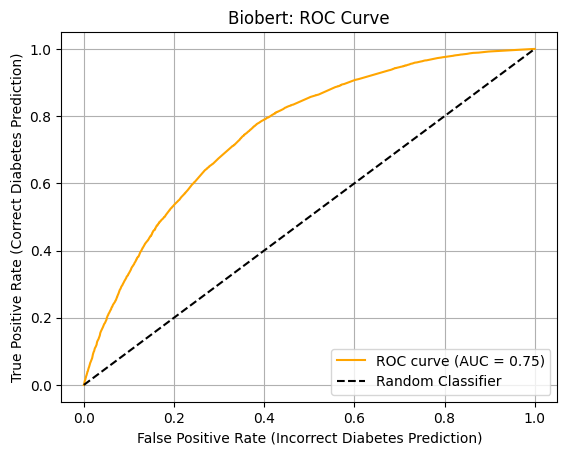

Biobert: Evaluation Results:
Recall: 0.7554696341003395
Precision: 0.6735328737178409
Accuracy: 0.6946435307431158
F1: 0.7121521913058939


In [40]:
graph_roc_auc(biobert_trainer, DiabetesDataset(test_encodings, y_test.values), "Biobert")

print_eval_metrics(biobert_trainer, "Biobert")

In [ ]:
# End of: Referenced/Used AI generated code and info from OpenAI GPT-4.1 through Github Copilot